# Dealing with Imbalanced Datasets
## Resampling
​
A widely adopted technique for dealing with highly unbalanced datasets is called resampling. It consists of removing samples from the majority class (under-sampling) and / or adding more examples from the minority class (over-sampling).
​
<img align = 'left' src = 'resampling.png' style = 'width:700px; hieght:600px' />

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from matplotlib import style
style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

In [63]:
df = pd.read_csv('creditcard.csv')
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
5,2,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0.0
6,4,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0.0
7,7,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0.0
8,7,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0.0
9,9,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0.0


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74800 entries, 0 to 74799
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    74800 non-null  int64  
 1   V1      74800 non-null  float64
 2   V2      74800 non-null  float64
 3   V3      74800 non-null  float64
 4   V4      74800 non-null  float64
 5   V5      74800 non-null  float64
 6   V6      74800 non-null  float64
 7   V7      74800 non-null  float64
 8   V8      74800 non-null  float64
 9   V9      74800 non-null  float64
 10  V10     74800 non-null  float64
 11  V11     74800 non-null  float64
 12  V12     74800 non-null  float64
 13  V13     74800 non-null  float64
 14  V14     74800 non-null  float64
 15  V15     74800 non-null  float64
 16  V16     74800 non-null  float64
 17  V17     74800 non-null  float64
 18  V18     74800 non-null  float64
 19  V19     74800 non-null  float64
 20  V20     74800 non-null  float64
 21  V21     74800 non-null  float64
 22

In [65]:
df.duplicated().sum()

291

In [66]:
df.drop_duplicates(inplace = True)

In [67]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64

In [68]:
from sklearn.impute import SimpleImputer                                          # import the class
imputer = SimpleImputer(missing_values = np.nan, strategy = 'mean')               # create an object
df[["V26","V27","V28","Amount"]] = imputer.fit_transform(df[["V26","V27","V28","Amount"]])            # tranform the data using object
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.620000,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.660000,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500000,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.990000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74795,55760,-0.364226,0.681327,1.371193,-0.017784,0.450493,-0.692570,0.815116,-0.150319,0.173609,...,-0.302637,-0.766926,0.057187,-0.223556,-0.316850,-0.883030,0.143946,-0.090509,18.410000,0.0
74796,55761,1.291584,-0.400218,0.171793,-0.529313,-0.804943,-0.659068,-0.624594,-0.060072,-0.765201,...,0.094680,0.176453,0.001036,0.007038,0.287631,-0.256908,0.041407,0.047873,39.800000,0.0
74797,55761,-0.383802,1.039889,0.999662,0.669443,0.772581,0.595312,0.582184,0.129054,-0.900366,...,0.182612,0.562618,-0.277140,-0.820199,-0.118142,-0.204115,0.042166,0.122790,7.360000,0.0
74798,55762,1.256229,-0.506944,0.482418,0.115658,-1.022264,-0.522547,-0.415670,-0.057159,-0.912658,...,-0.444295,-0.703718,0.020491,0.550057,0.403226,0.337180,-0.012798,0.008154,28.000000,0.0


In [69]:
imputer = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')
df[['Class']] = imputer.fit_transform(df[['Class']])            
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.620000,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.660000,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500000,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.990000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74795,55760,-0.364226,0.681327,1.371193,-0.017784,0.450493,-0.692570,0.815116,-0.150319,0.173609,...,-0.302637,-0.766926,0.057187,-0.223556,-0.316850,-0.883030,0.143946,-0.090509,18.410000,0.0
74796,55761,1.291584,-0.400218,0.171793,-0.529313,-0.804943,-0.659068,-0.624594,-0.060072,-0.765201,...,0.094680,0.176453,0.001036,0.007038,0.287631,-0.256908,0.041407,0.047873,39.800000,0.0
74797,55761,-0.383802,1.039889,0.999662,0.669443,0.772581,0.595312,0.582184,0.129054,-0.900366,...,0.182612,0.562618,-0.277140,-0.820199,-0.118142,-0.204115,0.042166,0.122790,7.360000,0.0
74798,55762,1.256229,-0.506944,0.482418,0.115658,-1.022264,-0.522547,-0.415670,-0.057159,-0.912658,...,-0.444295,-0.703718,0.020491,0.550057,0.403226,0.337180,-0.012798,0.008154,28.000000,0.0


In [70]:
df.nunique()

Time      35287
V1        73176
V2        73176
V3        73176
V4        73176
V5        73176
V6        73176
V7        73176
V8        73176
V9        73176
V10       73176
V11       73176
V12       73176
V13       73176
V14       73176
V15       73176
V16       73176
V17       73176
V18       73176
V19       73176
V20       73176
V21       73176
V22       73176
V23       73176
V24       73176
V25       73176
V26       73176
V27       73176
V28       73176
Amount    16564
Class         2
dtype: int64

<AxesSubplot:xlabel='Class', ylabel='count'>

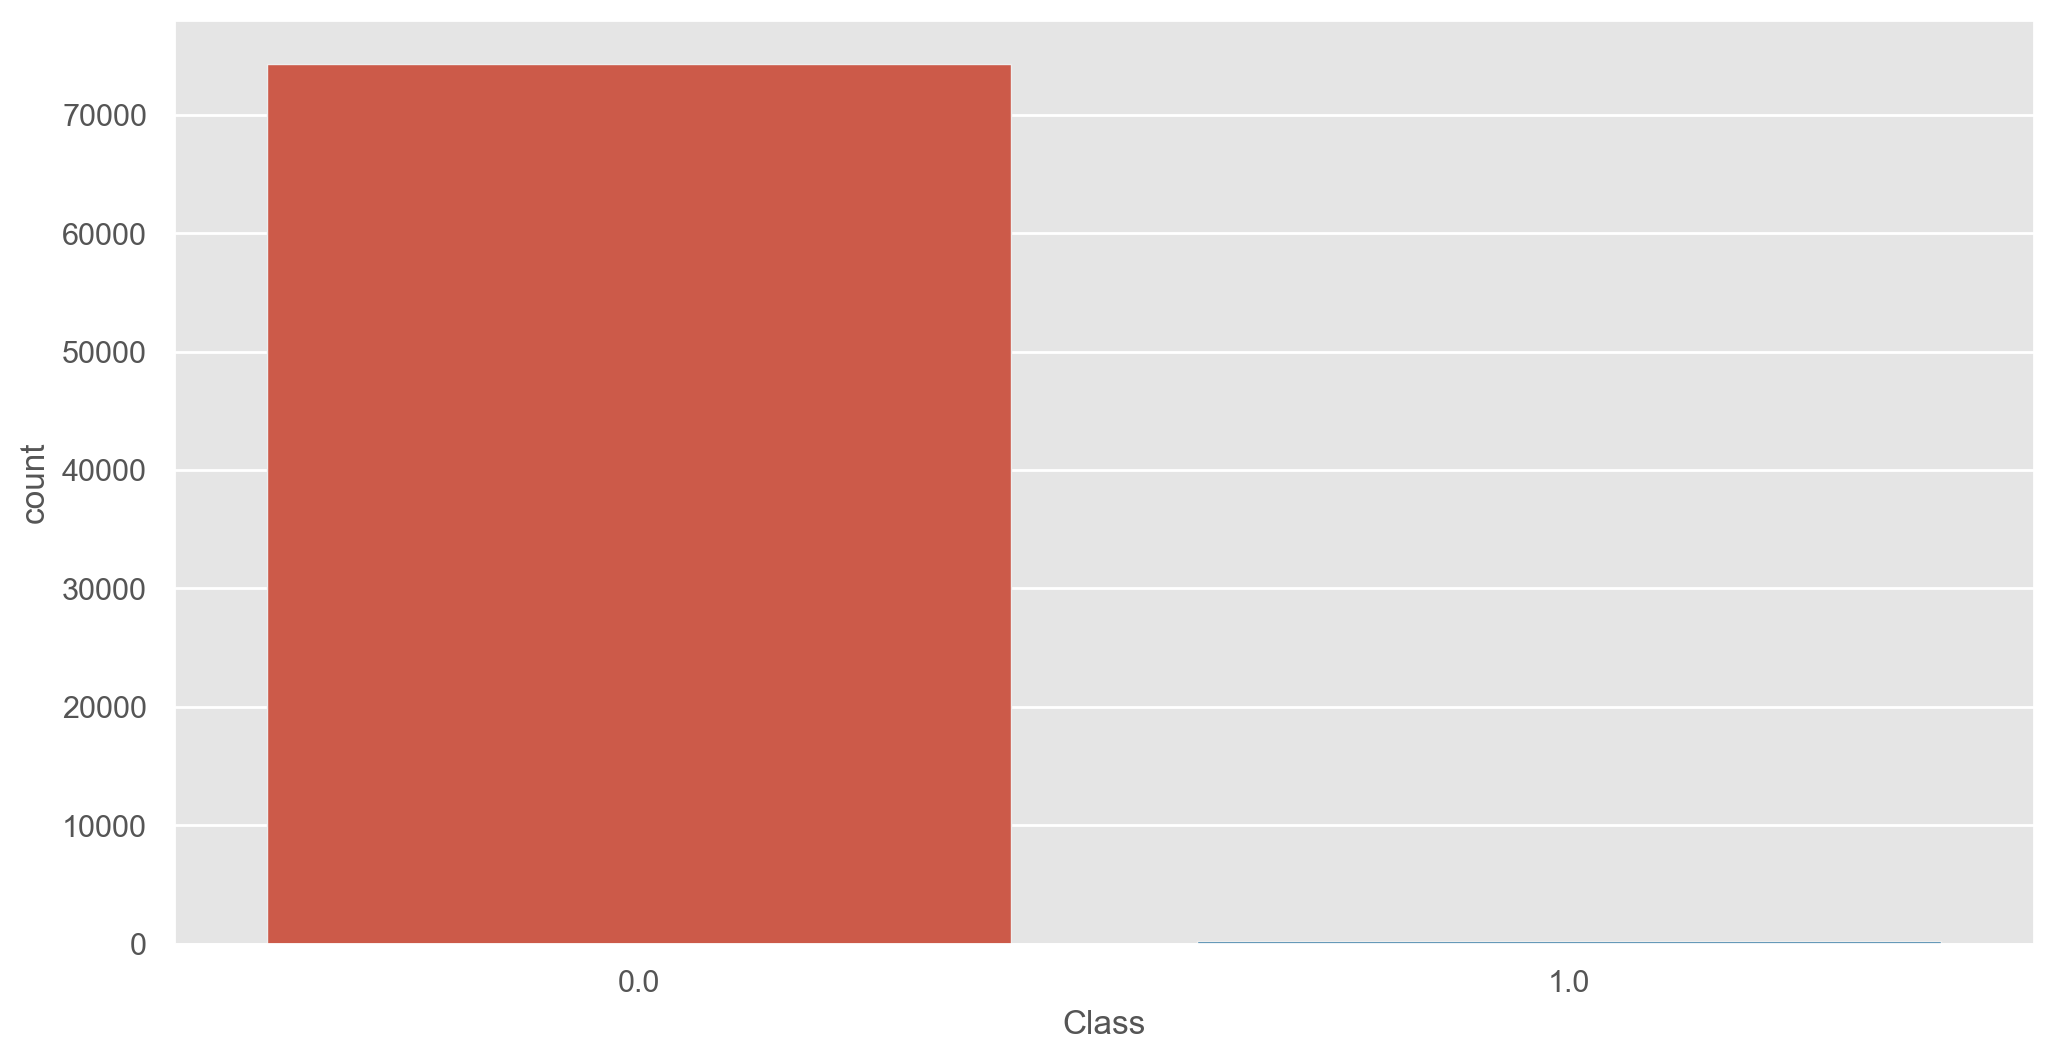

In [71]:
plt.figure(figsize = (12,6), dpi = 200)
sns.countplot(df.Class)

In [72]:
df.Class.value_counts()

0.0    74326
1.0      183
Name: Class, dtype: int64

In [73]:
class_ratio = df.Class.value_counts(normalize = True)
print('Percentage of fraudulent transactions     : ', class_ratio[1]*100)
print('Percentage of non fraudulent transactions : ', class_ratio[0]*100)

Percentage of fraudulent transactions     :  0.24560791313801017
Percentage of non fraudulent transactions :  99.75439208686198


In [74]:
X = df.drop('Class', axis = 1)
Y = df[['Class']]

print('Data Shape   : ', X.shape)
print('Labels Shape : ', Y.shape)

Data Shape   :  (74509, 30)
Labels Shape :  (74509, 1)


## Without Resampling

In [75]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

In [76]:
print('Training Data Shape   : ', x_train.shape)
print('Training Labels Shape : ', y_train.shape)
print('Testing Data Shape    : ', x_test.shape)
print('Testing Labels Shape  : ', y_test.shape)

Training Data Shape   :  (59607, 30)
Training Labels Shape :  (59607, 1)
Testing Data Shape    :  (14902, 30)
Testing Labels Shape  :  (14902, 1)


In [77]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(x_train, y_train)

LogisticRegression()

In [78]:
pred_train = classifier.predict(x_train)
pred_test  = classifier.predict(x_test)

print('Training Accuracy : ', accuracy_score(y_train, pred_train))
print('Testing  Accuracy : ', accuracy_score(y_test, pred_test))

Training Accuracy :  0.9983894509034174
Testing  Accuracy :  0.9982552677492954


In [79]:
print('Training Set f1 score : ', f1_score(y_train, pred_train))
print('Testing  Set f1 score : ', f1_score(y_test, pred_test))

Training Set f1 score :  0.6470588235294118
Testing  Set f1 score :  0.5185185185185185


In [80]:
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    #print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization


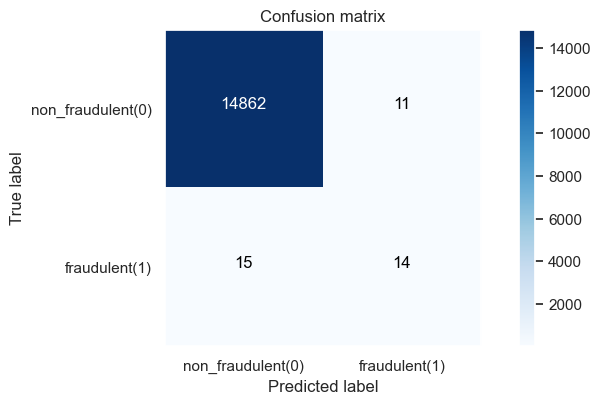

In [81]:
cm = confusion_matrix(y_test, pred_test)

plt.figure(figsize = (8,4), dpi = 100)
sns.set(rc = {'axes.grid' : False})
plot_confusion_matrix(cm, classes = ['non_fraudulent(0)','fraudulent(1)'])

In [82]:
print('Test set precision : ', precision_score(y_test, pred_test))
print('Test set recall    : ', recall_score(y_test, pred_test))

Test set precision :  0.56
Test set recall    :  0.4827586206896552


# ===============================================
## With Resampling

In [83]:
! pip install imbalanced-learn

### 1. Undersampling

In [84]:
from imblearn.under_sampling import NearMiss
nm_sampler = NearMiss()
x_sampled, y_sampled = nm_sampler.fit_resample(X, Y)

print('Data   : ', x_sampled.shape)
print('Labels : ', y_sampled.shape)

Data   :  (366, 30)
Labels :  (366, 1)


In [85]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_sampled, y_sampled, test_size = 0.2, random_state = 2)

print('Training Data Shape   : ', x_train.shape)
print('Training Labels Shape : ', y_train.shape)
print('Testing Data Shape    : ', x_test.shape)
print('Testing Labels Shape  : ', y_test.shape)

Training Data Shape   :  (292, 30)
Training Labels Shape :  (292, 1)
Testing Data Shape    :  (74, 30)
Testing Labels Shape  :  (74, 1)


In [86]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(x_train, y_train)

LogisticRegression()

In [87]:
pred_train = classifier.predict(x_train)
pred_test  = classifier.predict(x_test)

print('Training Accuracy : ', accuracy_score(y_train, pred_train))
print('Testing  Accuracy : ', accuracy_score(y_test, pred_test))

Training Accuracy :  0.9486301369863014
Testing  Accuracy :  0.972972972972973


In [88]:
print('Training Set f1 score : ', f1_score(y_train, pred_train))
print('Testing  Set f1 score : ', f1_score(y_test, pred_test))

print()
print('Test set precision : ', precision_score(y_test, pred_test))
print('Test set recall    : ', recall_score(y_test, pred_test))

Training Set f1 score :  0.9498327759197324
Testing  Set f1 score :  0.967741935483871

Test set precision :  0.967741935483871
Test set recall    :  0.967741935483871


### 2. Oversampling

In [89]:
from imblearn.over_sampling import SMOTE
smote_sampler = SMOTE()
x_sampled, y_sampled = smote_sampler.fit_resample(X, Y)

print('Data   : ', x_sampled.shape)
print('Labels : ', y_sampled.shape)

Data   :  (148652, 30)
Labels :  (148652, 1)


In [90]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_sampled, y_sampled, test_size = 0.2, random_state = 2)

print('Training Data Shape   : ', x_train.shape)
print('Training Labels Shape : ', y_train.shape)
print('Testing Data Shape    : ', x_test.shape)
print('Testing Labels Shape  : ', y_test.shape)

Training Data Shape   :  (118921, 30)
Training Labels Shape :  (118921, 1)
Testing Data Shape    :  (29731, 30)
Testing Labels Shape  :  (29731, 1)


In [91]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(x_train, y_train)

LogisticRegression()

In [92]:
pred_train = classifier.predict(x_train)
pred_test  = classifier.predict(x_test)

print('Training Accuracy : ', accuracy_score(y_train, pred_train))
print('Testing  Accuracy : ', accuracy_score(y_test, pred_test))

Training Accuracy :  0.9692653105843375
Testing  Accuracy :  0.9712085029094212


In [93]:
print('Training Set f1 score : ', f1_score(y_train, pred_train))
print('Testing  Set f1 score : ', f1_score(y_test, pred_test))

print()
print('Test set precision : ', precision_score(y_test, pred_test))
print('Test set recall    : ', recall_score(y_test, pred_test))

Training Set f1 score :  0.9689414603886779
Testing  Set f1 score :  0.9711064605414164

Test set precision :  0.9789710085749286
Test set recall    :  0.9633672649343692
